<div style="font-family: Calibri; font-size: 16px; background-color: #ccd5ae; padding: 10px 10px;">
    <h1>K-Nearest Neighbor + SMOTE</h1>
</div>

In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn import set_config
from sklearn.dummy import DummyClassifier
from scripts.plot import plot_two_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from scripts.plot_tetha import plot_model
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, make_scorer, confusion_matrix, fbeta_score

In [2]:
%load_ext autoreload
%autoreload 2
from scripts.scores import calc_predict_proba, calc_scores, confusion_matrix_display, print_evaluation

In [3]:
warnings.filterwarnings("ignore") 
set_config(display='diagram')
pd.options.display.precision=3
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<div style="font-family: Calibri; font-size: 16px; background-color: #faedcd; padding: 5px;">
    <h2>1. Loading Train and Test dataset</h2>
</div>

In [4]:
df = pd.read_csv("data/train.csv" )
df.shape

(255347, 18)

In [5]:
X = df.drop(columns=['Default', 'LoanID', 'DTIRatio', 'CreditScore'], axis=1)
y = df['Default']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
print(X_train.shape, X_test.shape,  y_train.shape, y_test.shape)

(178742, 14) (76605, 14) (178742,) (76605,)


<hr>
<div style="font-family: Calibri; font-size: 16px; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>2. Column Transformation</h2>
</div>

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler

<div style="font-family: Calibri; font-size: 18px; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h4>Univariate Analysis - Conclusion (Recap)</h4>    
    <ul>
            <li>HasCoSigner, HasDependents, HasMortgage are binary fields</li>
            <li>Education, EmploymentType, LoanPurpose, MaritalStatus are categorical data</li>
    </ul>        
    <h5>Transformation is done external to pipeline to avoid the redundent step In GridSearchCV
    </h5>
</div>

In [8]:
transformer = ColumnTransformer(
    [
        ('Binary', OneHotEncoder(), ['HasCoSigner', 'HasDependents', 'HasMortgage']),
        ('multi_category', OneHotEncoder(),  ['Education', 'EmploymentType', 'MaritalStatus']),
        ('Loan_category', OneHotEncoder(categories = [['Business', 'Home']], handle_unknown='ignore'), ['LoanPurpose']),    
    ], remainder=MinMaxScaler()
)

In [9]:
X_train = transformer.fit_transform(X_train)

In [10]:
X_test = transformer.transform(X_test)

<div style="font-family: Calibri; font-size: 16px; background-color: #e9edc9; padding: 5px;">
    <h4>- Using SMOTE</h4>
</div>

In [11]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks

In [12]:
# Initialize the SMOTE
rus = SMOTE()

# Fit and apply the undersampling
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

In [13]:
# The resampled data is now balanced
print("Shape of X before undersampling:", X_train.shape)
print("Shape of X after undersampling:", X_resampled.shape)
print("Value counts before undersampling:", pd.Series(y_train).value_counts())
print("Value counts after undersampling:", pd.Series(y_resampled).value_counts())

Shape of X before undersampling: (178742, 26)
Shape of X after undersampling: (316026, 26)
Value counts before undersampling: Default
0    158013
1     20729
Name: count, dtype: int64
Value counts after undersampling: Default
1    158013
0    158013
Name: count, dtype: int64


In [14]:
X_train, y_train = X_resampled, y_resampled

<div style="font-family: Calibri; font-size: 16px; background-color: #faedcd; padding: 5px;">
    <h2>3. KNearestNeighbor</h2>
    <font size=4>        
    <ul>
        <li>GridSearchCV</li>
    </ul>
    </font>
</div>

In [15]:
from sklearn.neighbors import KNeighborsClassifier

In [16]:
knn = KNeighborsClassifier(weights='distance')

In [17]:
param_grid = {
    'n_neighbors': list(range(5, 21, 2)),
}

In [18]:
cv = GridSearchCV(knn, param_grid, cv=5, scoring=make_scorer(fbeta_score, beta=2, pos_label=1), n_jobs=-1, verbose=True);

In [19]:
cv.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(weights='distance'),
             n_jobs=-1,
             param_grid={'n_neighbors': [5, 7, 9, 11, 13, 15, 17, 19]},
             scoring=make_scorer(fbeta_score, response_method='predict', beta=2, pos_label=1),
             verbose=True)

In [20]:
print("Best Parameters:", cv.best_params_)
print("Best CV Score:", cv.best_score_)

Best Parameters: {'n_neighbors': 5}
Best CV Score: 0.9341568290223506


In [21]:
model = cv.best_estimator_
model

KNeighborsClassifier(weights='distance')

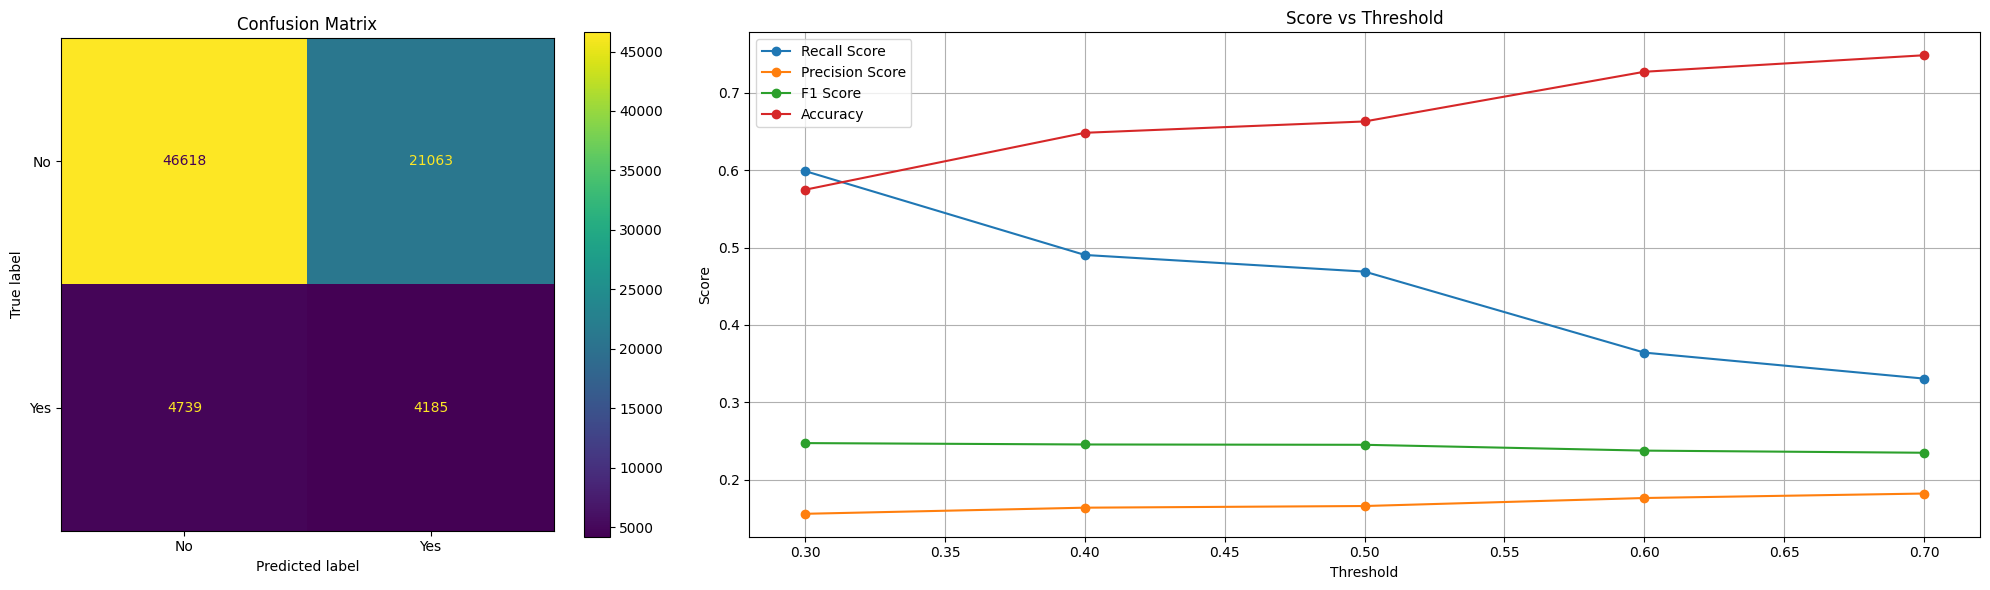

,Score,Percentage
0,Training Accuracy,100.00%
1,Test Accuracy,66.32%
2,Recall Score,33.06%
3,Precision Score,18.19%
4,Accuracy Score,74.88%
5,F1 Score,23.47%
6,ROC AUC Score,57.89%


In [22]:
scores_df, threshold_df = print_evaluation(model, X_train, y_train, X_test, y_test)
scores_df

In [23]:
threshold_df

,recall,precision,f1-score,accuracy
0.300,0.599,0.156,0.247,0.575
0.400,0.490,0.164,0.245,0.649
0.500,0.469,0.166,0.245,0.663
0.600,0.364,0.176,0.237,0.727
0.700,0.331,0.182,0.235,0.749
